## Mount the Drive so Colab can access your files

In [85]:
from google.colab import drive  # Gives Colab access to Google Drive.
import os  # Provides tools for checking folders and changing directories.

# Colab mounts Google Drive at this fixed location.
drive_path = '/content/drive'
my_drive_path = os.path.join(drive_path, 'My Drive')

# Check whether the Drive mount is already available.
try:
    drive_is_mounted = os.path.isdir(my_drive_path)
except OSError:
    drive_is_mounted = False

# Mount Google Drive only when needed.
if not drive_is_mounted:
    drive.mount(drive_path, force_remount=True)
else:
    print('Google Drive is already mounted.')

my_folder_path = 'Teaching/Distributed Energy Resources/Notebooks/HW5 - Buildings'
target_folder = os.path.join(my_drive_path, my_folder_path)

os.chdir(target_folder)
print('Working directory:', os.getcwd())

Google Drive is already mounted.
Working directory: /content/drive/My Drive/Teaching/Distributed Energy Resources/Notebooks/HW5 - Buildings


# Buildings

The objective of this notebook is to simulate the thermal behavior of a building using a 2R2C model. This model represents the building's thermal dynamics with two resistances (R) and two capacitances (C). Different control strategies are applied and the effects on energy consumption and indoor temperature are analyzed. First, let us review the structure of the 2R2C model.

A 2R2C model consists of two thermal resistances and two thermal capacitances. The resistances represent the thermal resistance between the indoor air and the building envelope, as well as the resistance between the building envelope and the outdoor environment. The capacitances represent the thermal mass of the indoor air and the building envelope. These relationships are shown in following equations:

$$ C \frac{dT(t)}{dt} = \frac{T_{m}(t) - T(t)}{R_{m}} + \frac{T_{out}(t) - T(t)}{R_{out}}+ q_{c}(t) + q_{e}(t) \tag{1} $$

$$ C_{m} \frac{dT_{m}(t)}{dt} = \frac{T(t) - T_{m}(t)}{R_{m}} \tag{2} $$

Where $T(t)$ is the indoor air temperature, $T_m(t)$ is the temperature of the thermal mass, $T_{out}(t)$ is the outdoor temperature, $q_{c}(t)$ is the controlled heat input (e.g., heating or cooling), $q_{e}(t)$ is the exogenous power input due to solar and internal gains, $R_{m}$ and $R_{out}$ is the thermal resistance in between the indoor air and the thermal mass and indoor and outdoor air repectively, and $C$ and $C_{m}$ is the thermal capcitance of air and the thermal mass repectively. Both the equations together can be written in a state-space form as follows:

$$
\frac{\text d}{\text d t} \begin{bmatrix}
T(t) \\
T_m(t)
\end{bmatrix} = \tilde A \begin{bmatrix}
T(t) \\
T_m(t)
\end{bmatrix} + \tilde B \left( q_c(t) + w(t) \right) \tag{3}
$$
Where,

$$
\tilde A = \begin{bmatrix}
-(1/R_m + 1/R_\text{out})/C & 1/(R_m C) \\
1/(R_m C_m) & -1/(R_m C_m)
\end{bmatrix} \tag{4}
$$

$$
\tilde B = \begin{bmatrix}
1/C \\
0
\end{bmatrix} , \quad w(t) = q_e(t) + T_\text{out}(t) / R_\text{out} \tag{5}
$$

This continuous-time state-space model can be discretized using a sampling time $\Delta t$ to obtain the discrete-time state-space model as follows:

$$
\begin{bmatrix}
T(k+1) \\
T_m(k+1) \\
\end{bmatrix} = A \begin{bmatrix}
T(k) \\
T_m(k) \\
\end{bmatrix} + B \left( q_c(k) + w(k) \right)
$$
where $A = e^{\Delta t \tilde A}$, $B = (A - I) \tilde A^{-1} \tilde B$ (can show $\tilde A^{-1}$ exists because $det(\tilde A) \neq 0$). The expansion of matrix $B$ is under the assumption that the matrix $\tilde A, \tilde B, q_c \text{ and } w$ are constant over sampling interval.

Now that the states-pace model of the building is defined, we can simulate the thermal behavior of the building under different control strategies. Two possible control strategies will be studied here: perfect setpoint tracking control and thermostatic control.


## Perfect Setpoint Tracking Control

In perfect setpoint tracking control, the heating or cooling system that provides the external heat input $q_c$ is assumed to provide the exact amount of heat required to maintain the indoor temperature at a desired setpoint $\hat T$. This means that the indoor temperature is always equal to the setpoint, and any deviations from the setpoint are corrected immediately by adjusting $q_c$ accordingly. Therefore, the control input $q_c$ can be calculated as follows:

$$
\begin{bmatrix}
T(k+1) \\
T_m(k+1) \\
\end{bmatrix} = \begin{bmatrix}
A_{11} & A_{12} \\
A_{21} & A_{22} \\
\end{bmatrix} \begin{bmatrix}
T(k) \\
T_m(k) \\
\end{bmatrix} + \begin{bmatrix}
B_1 \\
B_2 \\
\end{bmatrix} \left( q_c(k) + w(k) \right) \tag{6}
$$

$$
\hat{ q}_c(k) = \frac{ \hat T(k+1) - A_{11} T(k) - A_{12} T_m(k) }{ B_1 } - w(k) \tag{7}
$$

This derivation is based on rearranging the first row of the discrete-time state-space equation to solve for $q_c(k)$, given that $T(k+1) = \hat T(k+1)$. However, $q_c$ is constrained by the maximum heating and cooling power of the system, denoted as $\overline q_c$ and $\underline q_c$ respectively. To account for these constraints, the actual value of $q_c$ is clipped to ensure it remains within the allowable range:

$$
q_c(k) = { \max \left\{ \underline{q}_c(k), \min \left\{ \overline{q}_c(k), \hat{q}_c(k) \right\} \right\} } \tag{8}
$$


In [86]:
import numpy as np


def perfect_tracking_control(A, B, w, T0, Tset, qcMin, qcMax):
    """
    perfectTrackingControl implements (near-) perfect setpoint tracking
    control for a 2R2C building model. The control policy attempts to place
    the next temperature exactly at the user-specified setpoint, but may
    saturate at an equipment capacity limit.

    Input:
      A, the 2 x 2 discrete-time dynamics matrix
      B, the 2 x 1 discrete-time input matrix
      w, the K x 1 disturbance vector, kW
      T0, the 2 x 1 initial state vector, C
      Tset, the K+1 x 1 temperature setpoint vector, C
      qcMin, the K x 1 minimum HVAC thermal power capacity, kW
      qcMax, the K x 1 maximum HVAC thermal power capacity, kW

    Output:
      T, the 2 x K+1 indoor temperature vector, C
      qc, the K x 1 HVAC thermal power vector, kW
    """

    # dimensions
    K = len(w)

    # data storage
    T = np.zeros((2, K + 1))  # state [indoor air temperature; thermal mass temperature], C
    T[:, 0] = T0  # initial state, C
    qc = np.zeros(K)  # HVAC thermal power, kW

    # simulation
    for k in range(K):

        # control decision
        qc_hat = (Tset[k + 1] - np.dot(A[0, :], T[:, k])) / B[0, 0] - w[k]  # estimated HVAC power
        qc[k] = np.clip(qc_hat, qcMin[k], qcMax[k])  # apply power limits\

        # dynamic update
        T[:, k + 1] = np.dot(A, T[:, k]) + B.flatten() * (qc[k] + w[k])  # state update

    return T, qc


## Thermostatic Control

Thermostatic control represents the most commonly used control strategy in buildings. In this case, the heating or cooling system is turned on or off based on deviation of the indoor temperature from a desired setpoint $\hat T$ within a certain deadband $\delta$. The control input $q_c$ is defined as follows:

$$
q_c(k) = \underline{q}_c(k) + u(k) \left( \overline{q}_c(k) - \underline{q}_c(k) \right) \tag{9}

$$

where $u(k) \in \{0, 1\}$ is a binary variable that indicates whether the heating or cooling system is on or off. The value of $u(k)$ is determined based on the following conditions:

- If $T(k) < \hat T(k) - \delta$, then $u(k) = 1$.
- If $T(k) > \hat T(k) + \delta$, then $u(k) = 0$.

In all other cases, the value of $u(k)$ remains unchanged from the previous time step, i.e., $u(k) = u(k-1)$.




In [87]:
def thermostatic_control(A, B, w, T0, Tset, qcMin, qcMax, dT):
    """
    thermostaticControl implements thermostatic control for a 2R2C building
    model. The control policy turns the heater on if the indoor temperature
    drops below a minimum threshold, turns the heater off if the indoor
    temperature exceeds a maximum threshold, and otherwise does what it did
    at the previous time step.

    Input:
      A, the 2 x 2 discrete-time dynamics matrix
      B, the 2 x 1 discrete-time input matrix
      w, the K x 1 disturbance vector, kW
      T0, the 2 x 1 initial state vector, C
      Tset, the K+1 x 1 temperature setpoint vector, C
      qcMin, the K x 1 minimum HVAC thermal power capacity, kW
      qcMax, the K x 1 maximum HVAC thermal power capacity, kW
      dT, the thermostat deadband halfwidth, C

    Output:
      T, the 2 x K+1 indoor temperature vector, C
      qc, the K x 1 HVAC thermal power vector, kW
    """
    # dimensions
    K = len(w)

    # data storage
    T = np.zeros((2, K + 1))  # state [indoor air temperature; thermal mass temperature], C
    T[:, 0] = T0  # initial state, C
    qc = np.zeros(K)  # HVAC thermal power, kW
    u = np.zeros(K)  # HVAC on/off state, 0 or 1
    u0 = 0  # initial HVAC on/off state
    # simulation
    for k in range(K):
        # control decision

        if k == 0:
            u[k] = 0  # initial HVAC state
        else:
            u[k] = u[k - 1]  # maintain previous state

        if T[0, k] > Tset[k] + dT:
            u[k] = 0  # turn off HVAC

        if T[0, k] < Tset[k] - dT:
            u[k] = 1  # turn on HVAC

        qc[k] = qcMin[k] + u[k] * (qcMax[k] - qcMin[k])  # compute HVAC power

        T[:, k + 1] = np.dot(A, T[:, k]) + B.flatten() * (qc[k] + w[k])  # state update

    return T, qc

## Analysis

Now that both control strategies are defined, we can simulate the thermal behavior of the building under each strategy and analyze the results. To do so, first the basic building parameters, initial conditions, and external inputs need to be defined as shown in the following cell. Consider a $200m^2$ building with 2 floors simulated over a time period of 5 days with a sampling time of 15 minutes.

In [88]:
import pandas as pd
# ==============================================================================
# Parameters
# ==============================================================================
# Geometry
Af = 200  # floor area, m^2
N = 2  # number of stories

# Thermal capacitances
C = 0.0125 * Af  # air thermal capacitance, kWh/C
Cm = 12 * C  # mass thermal capacitance, kWh/C

# Thermal resistances
R = 1 / (0.016 * np.sqrt(N * Af))  # indoor-outdoor thermal resistance, C/kW
Rm = R / 6  # indoor-mass thermal resistance, C/kW

# Timing

dt = 1/60 #time step, h
t_span = pd.date_range("2022-12-22", "2022-12-27", freq="1min") #time span as datetime
K = len(t_span) # number of time steps
t = np.arange(0, K * dt, dt) # time span, h

# Heater capacity constraints
qcMin = np.zeros(K) #minimum HVAC thermal power, kW
qcMax = 14 * np.ones(K) #maximum HVAC thermal power, kW

In order to use the discrete-time state-space model defined earlier, we first need to compute the matrices A and B based on the building parameters and the sampling time. This can be done using the following function:

In [89]:
from scipy.linalg import expm
# ==============================================================================
# 2R2C model
# ==============================================================================
# Continuous-time dynamics matrices
Ac = np.zeros((2, 2))  # continuous-time dynamics matrix
Bc = np.zeros((2, 1))  # continuous-time input matrix
Ac[0, 0] = -(1 / R + 1 / Rm) / C
Ac[0, 1] = 1 / (Rm * C)
Ac[1, 0] = 1 / (Rm * Cm)
Ac[1, 1] = -1 / (Rm * Cm)
Bc[0, 0] = 1 / C
# Ac = np.array([[-(1 / R + 1 / Rm) / C, 1 / (Rm * C)],
#                [1 / (Rm * Cm), -1 / (Rm * Cm)]])
# Bc = np.array([[1 / C], [0]])

# Discrete-time dynamics matrices

A = expm(Ac * dt)  # discrete-time state-to-state matrix
B = np.linalg.solve(Ac, (A - np.eye(2)) @ Bc)  # discrete-time input-to-state matrix

Next the weather data and internal gains need to be defined.

In [90]:

def import_weather(file_name, t_span):
    """
    importWeather imports and processes weather data from a CSV file
    generated by OikoLab.

    Input:
      fileName, the name of the OikoLab CSV weather file.
      t, the datetime span.

    Output:
      temperature, the outdoor temperature in C
      totalHorizontal, the total solar shortwave irradiance on a horizontal surface in kW/m^2
      beamNormal, the beam solar shortwave irradiance on a normal surface in kW/m^2
      diffuseHorizontal, the diffuse solar shortwave irradiance on a horizontal surface in kW/m^2
      offsetGMT, (local time) - (Greenwich mean time) in hours
    """

    # import raw data
    weather_data = pd.read_csv(file_name)

    # extract data and convert units
    weather_data['timestamp'] = pd.to_datetime(
        weather_data.iloc[:, 0], format='%m/%d/%y %H:%M', errors='coerce'
    )

    # Fix year only if it's before 2000 to avoid overflow issues
    mask = weather_data['timestamp'].dt.year < 2000
    weather_data.loc[mask, 'timestamp'] = weather_data.loc[mask, 'timestamp'].apply(
        lambda x: x.replace(year=x.year + 2000)
    )

    # convert UTC to local time
    offsetGMT = weather_data.iloc[:, 4].values
    weather_data['timestamp'] += pd.to_timedelta(offsetGMT, unit='h')

    # set timestamp as index
    weather_data.set_index('timestamp', inplace=True)

    # extract data and convert units
    temperature = weather_data.iloc[:, 5].values  # outdoor air temperature, C
    total_horizontal = weather_data.iloc[:, 6].values / 1000  # total horizontal shortwave irradiance, kW/m^2
    beam_normal = weather_data.iloc[:, 7].values / 1000  # beam normal shortwave irradiance, kW/m^2
    diffuse_horizontal = weather_data.iloc[:, 8].values / 1000  # diffuse horizontal shortwave irradiance, kW/m^2

    # fill any missing data
    weather_data.interpolate(method='linear', inplace=True)

    # pack the data into a timetable object
    weather_data = weather_data.reindex(t_span).interpolate(method='linear')

    # retime to the desired time steps
    temperature = weather_data.iloc[:, 5].values
    total_horizontal = weather_data.iloc[:, 6].values / 1000
    beam_normal = weather_data.iloc[:, 7].values / 1000
    diffuse_horizontal = weather_data.iloc[:, 8].values / 1000
    offsetGMT = weather_data.iloc[:, 4].values

    # fill any missing data again
    temperature = pd.Series(temperature).interpolate(method='linear').values
    total_horizontal = pd.Series(total_horizontal).interpolate(method='linear').values
    beam_normal = pd.Series(beam_normal).interpolate(method='linear').values
    diffuse_horizontal = pd.Series(diffuse_horizontal).interpolate(method='linear').values
    offsetGMT = pd.Series(offsetGMT).interpolate(method='linear').values

    return temperature, total_horizontal


In [91]:
def import_electricity(file_name, t_span):
    """
    importElectricity imports and processes electrical load data from the
    MFRED (Multi Family Residential Electricity Demand) csv file. This
    dataset contains electricity demand profiles for 390 multifamily
    apartments in New York City, anonymized by averaging the 390 into 26
    groups of 15 apartments each.

    Input:
      fileName, the name of the MFRED file.
      t, the datetime span.

    Output:
      P, a length(t) x 26 matrix of electricity demand data
    """

    # import raw data
    raw_data = pd.read_csv(file_name)

    # extract power data
    raw_data['timestamp'] = pd.to_datetime(
        raw_data.iloc[:, 0],
        format='%m/%d/%y %H:%M',
        errors='coerce'
    )

    # fix year from e.g. 20 to 2020
    if raw_data['timestamp'].dt.year.iloc[0] < 2000:
        raw_data.loc[:, 'timestamp'] = raw_data['timestamp'].apply(lambda x: x.replace(year=x.year + 2000))

    # convert UTC to eastern
    raw_data['timestamp'] -= pd.Timedelta(hours=5)

    # set timestamp as index
    raw_data.set_index('timestamp', inplace=True)

    # indices of kW columns
    power_columns = raw_data.columns[4::3]
    individual_power = raw_data[power_columns].copy()  # individual power profiles

    # fill any missing data
    individual_power.interpolate(method='linear', inplace=True)

    # retime to the desired time span
    individual_power = individual_power.reindex(t_span).interpolate(method='linear')

    # fill any missing data again
    individual_power.interpolate(method='linear', inplace=True)

    # extract power data from dataframe into matrix
    P = individual_power.to_numpy()

    return P


Therefore, the two functions can be used to import the weather data and internal gains from CSV files. These will be imported into our simulation and used to calculate the disturbance input $w(t)$ at each time step as shown in equation (5). The plug power data obtained form the above function is summed with the solar irradiance and the internal gains to obtain the total exogenous heat input $q_e(t)$.

In [92]:
# ==============================================================================
# Input signals
# ==============================================================================
# Weather data import
weather_file = 'boulder-2022-weather.csv'
Tout, I = import_weather(weather_file, t_span)

# Electricity data import
electricity_file = 'MFRED-2019-NYC-Apartments-Electricity-Data.csv'
t_elec = t_span.map(lambda x: x.replace(year=2019))
plug_powers = import_electricity(electricity_file, t_elec)

# Exogenous thermal power
qe = (plug_powers[:, np.random.randint(plug_powers.shape[1])] +  # from plugged-in devices
      0.19 * np.sqrt(N * Af) * I +  # from the sun
      1 + (0.5 / 3) * np.random.randn(K))  # from everything else
# Disturbance
w = qe + Tout / R  # kW

/tmp/ipykernel_1187/375688561.py:46: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  weather_data.interpolate(method='linear', inplace=True)
/tmp/ipykernel_1187/375688561.py:49: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  weather_data = weather_data.reindex(t_span).interpolate(method='linear')


Consider a indoor temperature setpoint ($\hat T$) of $21\degree C$ during occupied hours (6AM TO 10PM) and $18.5\degree C$ during unoccupied hours for both control strategies.

In [93]:
# Indoor temperature setpoint
Tset = 21 * np.ones(len(t) + 1) #day indoor temperature setpoint, C
Tset[:len(t)][np.mod(t, 24) < 6] = 18.5 #night setpoint, C
Tset[:len(t)][np.mod(t, 24) > 22] = 18.5 #night setpoint, C

Let us now visulalize the outdoor air temperature and the exogenous heat input over the simulation period.

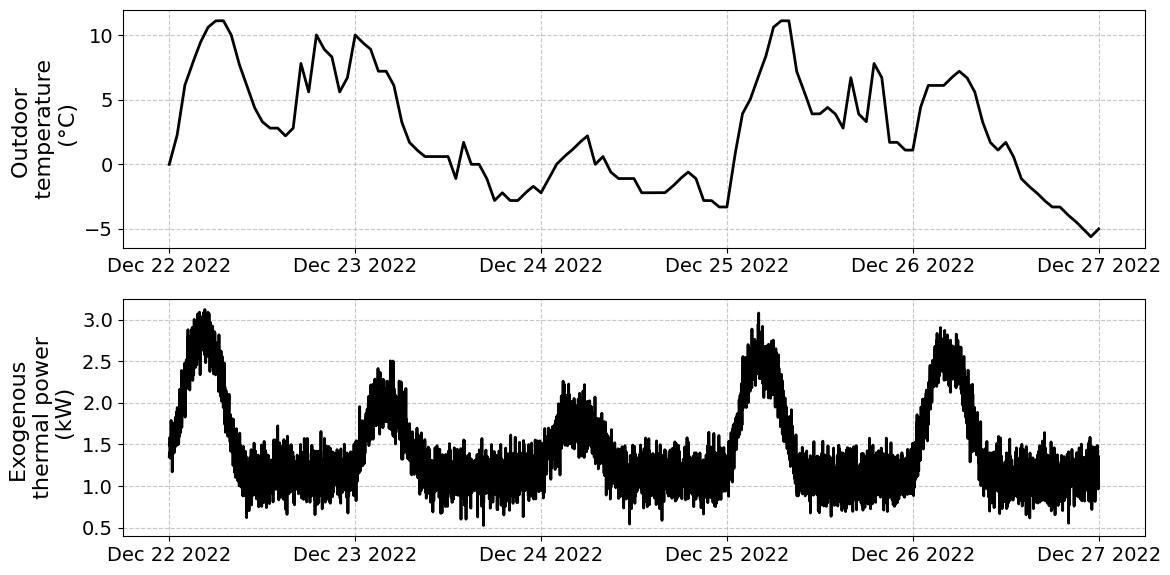

In [94]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
# ==============================================================================
# Graphics settings
# ==============================================================================

plt.rc('font', size=15)
plt.rc('axes', titlesize=15, labelsize=12)
plt.rc('xtick', labelsize=12)
plt.rc('ytick', labelsize=12)
plt.rc('legend', fontsize=11)
plt.rc('figure', titlesize=20)
plt.rc('lines', linewidth=2)
# ==============================================================================
# Visualization of inputs
# ==============================================================================
plt.figure(1,figsize=(12, 6))
plt.clf()

# First subplot (Outdoor Temperature)
ax1 = plt.subplot(2, 1, 1)
plt.plot(t_span, Tout, 'k')
plt.ylabel('Outdoor \n temperature \n (°C)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %Y'))

# Second subplot (Exogenous Thermal Power)
ax2 = plt.subplot(2, 1, 2)
plt.plot(t_span, qe, 'k')
plt.ylabel('Exogenous \n thermal power \n (kW)', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %Y'))

plt.tight_layout()
plt.show()

Now that the external inputs are defined, we can simulate the thermal behavior of the building under both control strategies. First let us write a function to visualize the results of the simulation in the following cell.

In [95]:

def plot_rc_results(t, Tset, T, Tm, Qdotc, fig_num):
    """
    % plotRCresults plots RC thermal circuit simulation results.
    %
    % Input:
    %   t, the K vector time span in h
    %   Tset, the indoor temperature setpoint in C
    %   T, the K+1 vector indoor air temperature in C
    %   Tm, the K+1 vector thermal mass temperature in C
    %   Qdotc, the K vector HVAC thermal power in kW
    %   figNum, the figure number to plot into
    """

    # parameters
    t_lim = [t[0], t[-1]]  # Time axis limits, h
    T_lim = [np.floor(np.min(Tset)), np.ceil(np.max(Tset)) + 1]  # Temperature axis limits

    plt.figure(fig_num, figsize=(12, 6))
    plt.clf()

    # Temperature plot
    plt.subplot(2, 1, 1)
    plt.step(t, T, 'k', where='post', label='Air')
    plt.step(t, Tm, 'r', where='post', label='Mass')
    plt.step(t, Tset, 'm--', where='post', label='Setpoint')
    plt.xlim(t_lim)
    plt.ylim(T_lim)
    plt.ylabel('Temperature \n (°C)', fontsize=12)
    #plt.legend(['Air', 'Mass', 'Setpoint'], loc='upper center', ncol=3, frameon=False)
    plt.legend(['Air', 'Mass', 'Setpoint'], loc='upper center', bbox_to_anchor=(0.5, 1.2), ncol=3, frameon=False)

    # Thermal power plot
    plt.subplot(2, 1, 2)
    plt.step(t, Qdotc, 'k', where='post')
    plt.xlim(t_lim)
    plt.ylabel('Thermal Power \n (kW)')
    plt.xlabel('Hour (0 = midnight)')

    plt.tight_layout()
    plt.show()


Finally the simulation can be run for both control strategies and the results can be visualized using the function defined above. First, consider the perfect setpoint tracking control strategy.

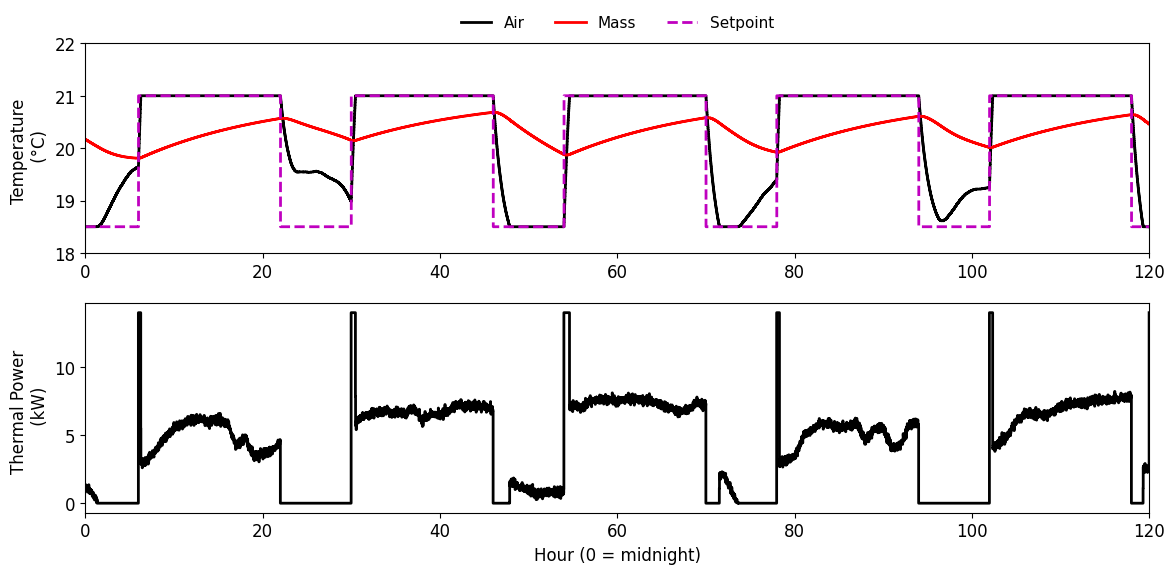

In [96]:

# %% (near-) perfect tracking simulation
# initial state
T0 = np.array([Tset[0], np.mean(Tset)])  # initial air and mass temperature, C

# simulation
T1, qc1 = perfect_tracking_control(A, B, w, T0, Tset, qcMin, qcMax)

# plot results
plot_rc_results(t, Tset[:-1], T1[0, :-1], T1[1, :-1], qc1, 2)



Now consider the termostatic control strategy.

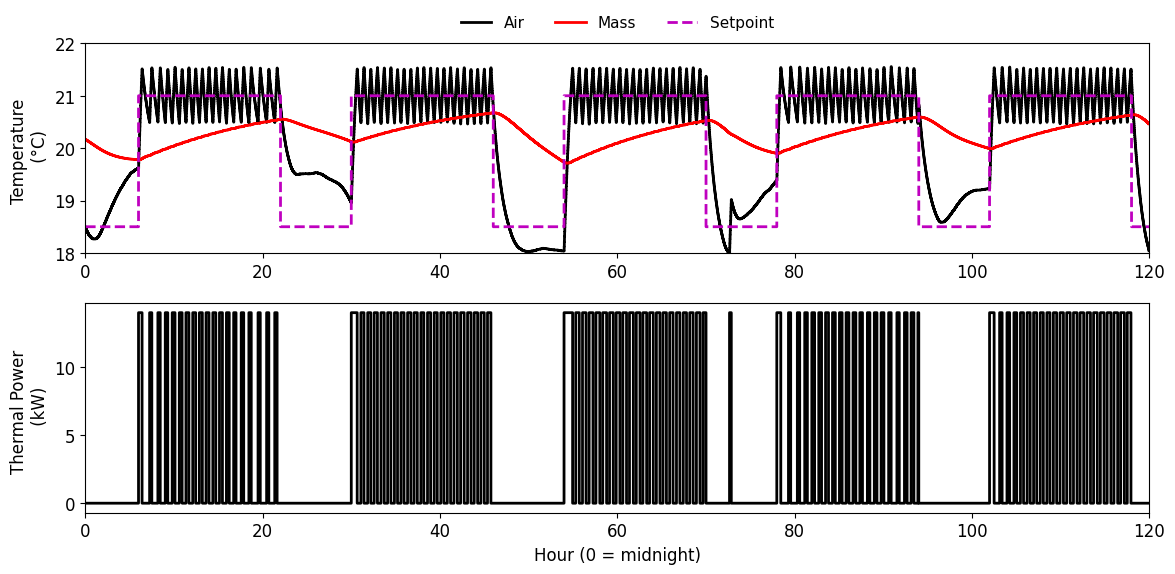

In [97]:
# ==============================================================================

# %% thermostatic control simulation
# simulation
dT = 0.5  # thermostat deadband halfwidth, C
T2, qc2 = thermostatic_control(A, B, w, T0, Tset, qcMin, qcMax, dT)

# plot results
plot_rc_results(t, Tset[:-1], T2[0, :-1], T2[1, :-1], qc2, 3)

## Discussion

In perfect setpoint tracking control the building is able to perfectly maintain the temperature at the setpoint provided the system has enough capacity. As soon as there is a change in the setpoint the HVAC system is called on to supply the maximum amount of heat which isn't enough for the indoor temperature to reach the setpoint at that moment in time. So the indoor temp rises but doesn't reach the setpoint. Gradually the amount of heating required decreases and so the heating system appears sufficient.

In thermostatic control a similar issue is observed during a setpoint change which is that the HVAC system doesn't have enough capacity to immediately reach the deadband within the next timestep and so has to operate at maximum capacity for a while. However, once the deadband is reached, the building experiences severe oscillations indoor temperature because of the proposed control strategy that keeps switching the HVAC system on/off operating at max capacity with no part load performance.